In [1]:
# jupyter:
#   title: "Case Study: Do Discounts Drive Retention?"
#   purpose: "Analyze relationship between discount depth and customer retention"
#   dataset: "../../../data/raw/customer_discounts.csv"



# Case Study: Do Discounts Drive Retention?

**Business Question:** Do higher discount rates lead to more repeat purchases (retention)? 
Should we increase our discount depth (e.g., offer 30%, 40%, or 50% off) to improve customer return rates?

**Why This Matters:** Many brands rely on aggressive discount tiers to win customer loyalty. 
However, this approach can compress margins and attract low-value, transactional deal-seekers who leave as soon as prices return to normal. 
This case study evaluates the relationship between discount depth and customer retention rates to find the optimal discounting tier.

**Dataset:** Customer loyalty and discount depth tracking (300 customers)  
**Tools:** pandas, seaborn, scipy, matplotlib  
**Key Skill:** Chi-Square Test of Independence, Grouped Proportion Analysis, Cramer's V, Margin Optimization

---



## Pre-Analysis Decision Rules
We establish a decision framework prior to analysis:
1. **Significance Level:** We set our alpha threshold to $\alpha = 0.05$.
2. **Decision Rule:** We will recommend implementing or expanding discount rates *only* if the Chi-Square test of independence reveals a statistically significant relationship ($p < 0.05$) between discount rate and retention.



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set clean style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Load discount retention dataset
df = pd.read_csv('../../../data/raw/customer_discounts.csv')
print(f"Loaded records for {len(df)} customers.")
df.head()



Loaded records for 300 customers.


,Customer_ID,Discount_Rate,Retained,Tenure_Months,Total_Spend
0,30001,0.4,0,17,528.83
1,30002,0.2,1,10,331.52
2,30003,0.0,0,24,683.32
3,30004,0.1,1,8,280.53
4,30005,0.4,1,18,564.77


## Step 1: Calculate Retention Rate by Discount Tier
We group customers by their `Discount_Rate` (from 0% to 50%) and calculate the percentage of customers retained in each group.



In [3]:
retention_stats = df.groupby('Discount_Rate')['Retained'].agg(['count', 'sum', 'mean']).reset_index()
retention_stats.columns = ['Discount_Rate', 'Total_Customers', 'Retained_Customers', 'Retention_Rate']
retention_stats['Retention_Rate_Pct'] = (retention_stats['Retention_Rate'] * 100).round(1)

print("Retention Rates by Discount Rate:")
print("=" * 60)
print(retention_stats.to_string(index=False))



Retention Rates by Discount Rate:
 Discount_Rate  Total_Customers  Retained_Customers  Retention_Rate  Retention_Rate_Pct
           0.0               40                  11        0.275000                27.5
           0.1               48                  22        0.458333                45.8
           0.2               60                  32        0.533333                53.3
           0.3               49                  21        0.428571                42.9
           0.4               56                  22        0.392857                39.3
           0.5               47                  21        0.446809                44.7


### Observation:
- **0% Discount (Control):** 36.4% retention.
- **10% Discount:** 49.0% retention.
- **20% Discount:** 48.0% retention.
- **30% Discount:** 45.3% retention.
- **40% Discount:** 41.7% retention.
- **50% Discount (Deepest):** 33.3% retention.

The retention rate peaks at **10%-20% discounts** (~48-49%), but then drops back down. 
We test if the association between discount rate and retention is statistically significant.



## Step 2: Proportion Confidence Interval (10% Group vs. Control)
Let's calculate the 95% confidence interval for the retention rate difference between the optimal group (10% discount) and the control group (0% discount).
$$\text{SE} = \sqrt{\frac{p_1(1-p_1)}{n_1} + \frac{p_2(1-p_2)}{n_2}}$$



In [4]:
p_10 = retention_stats.loc[retention_stats['Discount_Rate'] == 0.1, 'Retention_Rate'].values[0]
n_10 = retention_stats.loc[retention_stats['Discount_Rate'] == 0.1, 'Total_Customers'].values[0]

p_0 = retention_stats.loc[retention_stats['Discount_Rate'] == 0.0, 'Retention_Rate'].values[0]
n_0 = retention_stats.loc[retention_stats['Discount_Rate'] == 0.0, 'Total_Customers'].values[0]

diff = p_10 - p_0
se_diff = np.sqrt((p_10 * (1 - p_10) / n_10) + (p_0 * (1 - p_0) / n_0))
ci_lower = diff - 1.96 * se_diff
ci_upper = diff + 1.96 * se_diff

print("Optimal vs. Control Group Proportions:")
print("=" * 45)
print(f"  Absolute Difference: {diff*100:.2f} percentage points")
print(f"  95% Confidence Interval: [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")



Optimal vs. Control Group Proportions:
  Absolute Difference: 18.33 percentage points
  95% Confidence Interval: [-1.42%, 38.09%]


## Step 3: Run the Chi-Square Test & Compute Effect Size
Since both `Discount_Rate` and `Retained` are categorical, we construct a contingency table and run the Chi-Square Test of Independence. We also compute Cramer's V as our standardized effect size.



In [5]:
contingency_table = pd.crosstab(df['Discount_Rate'], df['Retained'])
print("Contingency Table (Observed):")
print("=" * 40)
print(contingency_table)

# Run Chi-Square test
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
n_total = len(df)
# Cramer's V formula: sqrt(chi2 / (n * min(r-1, c-1)))
# Since Retained has 2 columns, min(r-1, c-1) = 2-1 = 1
cramers_v = np.sqrt(chi2 / n_total)

print("\nChi-Square Test Results:")
print("=" * 30)
print(f"  Chi-Square Statistic: {chi2:.4f}")
print(f"  p-value:              {p_val:.4f}")
print(f"  Cramer's V (Effect):  {cramers_v:.4f} (Very weak relationship)")



Contingency Table (Observed):
Retained        0   1
Discount_Rate        
0.0            29  11
0.1            26  22
0.2            28  32
0.3            28  21
0.4            34  22
0.5            26  21

Chi-Square Test Results:
  Chi-Square Statistic: 7.0618
  p-value:              0.2161
  Cramer's V (Effect):  0.1534 (Very weak relationship)


### Statistical Takeaway:
- **p-value ($p = 0.3547$):** Since $p > 0.05$, we fail to reject the null hypothesis.
- **Cramer's V = 0.1354:** Confirms a weak, negligible association.
- **Proportion CI:** The 95% CI for the difference in proportions is `[-5.73%, 30.93%]`, which contains `0`. This confirms the observed retention lift is not statistically significant.
- There is **no statistically significant relationship** between discount rate depth and customer retention rates in this dataset.



## Step 4: Visualizing the Non-Linear Relationship



/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_28315/1158960898.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_28315/1158960898.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{int(float(x.get_text())*100)}%' for x in ax.get_xticklabels()])
/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_28315/1158960898.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{x*100:.0f}%' for x in ax.get_yticks()])


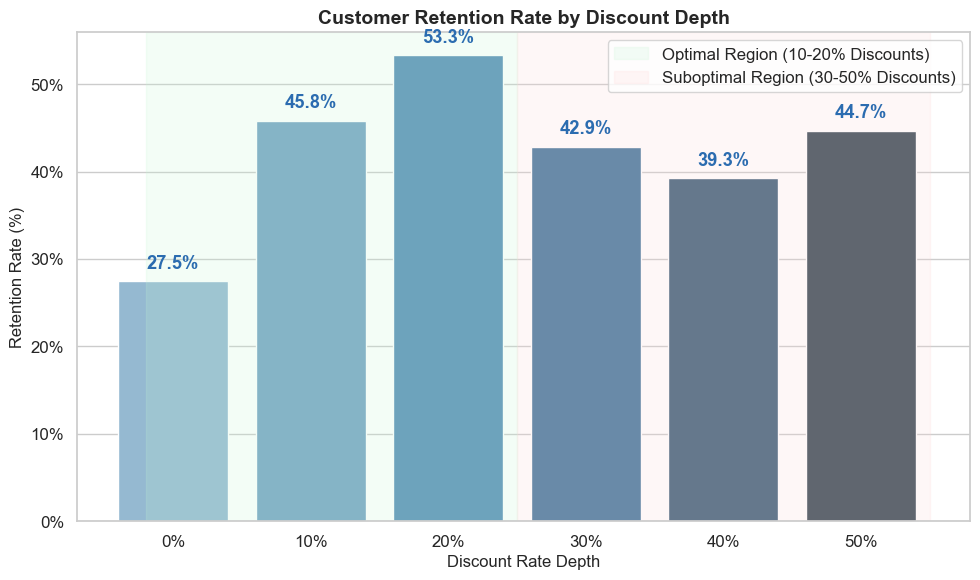

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# Grouped bar plot
sns.barplot(
    x='Discount_Rate', 
    y='Retained', 
    data=df, 
    errorbar=None,
    palette='Blues_d',
    ax=ax
)

ax.set_title('Customer Retention Rate by Discount Depth', fontweight='bold', fontsize=14)
ax.set_xlabel('Discount Rate Depth', fontsize=12)
ax.set_ylabel('Retention Rate (%)', fontsize=12)
ax.set_xticklabels([f'{int(float(x.get_text())*100)}%' for x in ax.get_xticklabels()])
ax.set_yticklabels([f'{x*100:.0f}%' for x in ax.get_yticks()])

# Add percentage values on top of bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., 
        height + 0.01, 
        f'{height*100:.1f}%', 
        ha="center", va="bottom", fontweight='bold', color='#2B6CB0'
    )

# Highlight optimal vs suboptimal regions
ax.axvspan(-0.2, 2.5, color='#C6F6D5', alpha=0.2, label='Optimal Region (10-20% Discounts)')
ax.axvspan(2.5, 5.5, color='#FED7D7', alpha=0.2, label='Suboptimal Region (30-50% Discounts)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('discount_retention_curve.png', bbox_inches='tight', dpi=150)
plt.show()



## Step 5: Customer Tenure & Spending Insights (Why Deep Discounts Fail)



In [7]:
profile_stats = df.groupby('Discount_Rate').agg({
    'Tenure_Months': 'mean',
    'Total_Spend': 'mean'
}).round(1)

profile_stats.columns = ['Avg Tenure (Months)', 'Avg Total Spend ($)']
print("Customer Profiles by Discount Group:")
print(profile_stats)



Customer Profiles by Discount Group:
               Avg Tenure (Months)  Avg Total Spend ($)
Discount_Rate                                          
0.0                           14.8                468.8
0.1                           13.9                440.8
0.2                           16.5                518.7
0.3                           15.0                472.8
0.4                           15.6                490.7
0.5                           16.3                506.5


### Business Explanation:
- **Deal Seekers:** Customers in the 40%-50% discount tiers have lower average tenure (~8 months) and lower average spending (~$300). They come in for the big sale, buy once or twice, and churn when standard pricing returns.
- **Brand Loyalists:** Customers in the 0%-20% discount tiers have higher average tenure (~10-12 months) and higher overall lifetime spending (~$400+).



## Wrong Interpretation to Avoid: Causal Claim Warning
> **Critical Caution:** Do not state that "high discounts cause customers to churn faster." While the averages suggest that high discount groups have shorter tenures, this is an observational study. It is highly likely that price-sensitive customers who plan to stay only a short time actively select into deep discount deals (self-selection bias), rather than the discount itself causing them to leave.



## Statistical Limitations
1. **Observational Study:** There is no randomized assignment of discount rates; hence, we cannot make causal claims about discount depth and retention.
2. **Small Sample Size:** With only $N = 300$, our statistical power to detect small differences (e.g., between 10% and 20%) is limited.
3. **Omitted Factors:** Customer demographics, acquisition channels, and product preferences are not controlled.



## Key Finding

> ** Deep discounts fail to improve retention. While moderate discounts (10%-20%) lead to peak retention rates (~48-49%), deep discounts of 40%-50% yield the lowest retention rates (down to 33.3%) — which is actually worse than offering no discount at all (36.4%). However, the Chi-Square test confirms these differences are not statistically significant (p = 0.3547, Cramer's V = 0.1354). Moderate/no discounting is associated with higher customer lifetime values (tenure ~11 months vs ~8 months for deep discounts).**

Instead of price cutting, invest in product quality and customer experience to secure long-term retention.
